# Depetris-Chauvin, Durante, and Campante (2020): fixed-effect-residualized DML estimates

This notebook re-estimates the main Table 2 and Table 4 Afrobarometer results from *Building Nations through Shared Experiences: Evidence from African Football*. It first partials out the original fixed effects and then applies partially linear double machine learning (DML) to the residualized outcome, treatment, and controls.

Identification continues to come from interview timing around national-team matches. DML changes only the adjustment for observed residualized covariates.

## Published Table 2 and Table 4 benchmarks

| Target | Outcome | Treatment | Published estimate | Published SE | Published N |
|---|---|---|---:|---:|---:|
| Table 2, col. 6 | `ethnic_sentiment` | `post_victory` | -0.053 | 0.016 | 37,060 |
| Table 4, col. 1 | `trust_people_d` | `post_victory` | 0.063 | 0.021 | 9,355 |
| Table 4, col. 2 | `trust_intergroup_d` | `post_victory` | 0.140 | 0.040 | 7,973 |
| Table 4, col. 3 | `like_neighbors_ethnicities_d` | `post_victory` | 0.102 | 0.030 | 7,511 |
| Table 4, col. 4 | `dislike_foreign_neighbors_d` | `post_victory` | 0.019 | 0.018 | 7,497 |

Table 2 column 6 and Table 4 columns 1, 3, and 4 use `reghdfe`. Table 4 column 2 uses `reg` with explicit fixed-effect indicators, so its default sample does not apply `reghdfe` singleton removal.

## 1. Runtime and dependencies

This cell verifies a CUDA runtime, imports the numerical and GPU libraries, records package availability, and defines shared conversion and inference helpers.

In [ ]:
from pathlib import Path
import importlib.util
import os
import subprocess
import sys
import warnings
import json
import math
import pickle

import numpy as np
import pandas as pd


def package_available(name):
    return importlib.util.find_spec(name) is not None


def ensure_colab_gpu_libraries(auto_install=True):
    """Verify CUDA availability and install RAPIDS/cuML if needed."""
    gpu_check = subprocess.run(
        ["nvidia-smi"],
        text=True,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
    )
    print(gpu_check.stdout)
    if gpu_check.returncode != 0:
        raise RuntimeError(
            "No CUDA GPU is visible. In Colab, choose Runtime > Change runtime type > GPU, "
            "then restart and run the notebook again."
        )

    missing = [pkg for pkg in ["cuml", "cudf", "cupy"] if importlib.util.find_spec(pkg) is None]
    if missing:
        if not auto_install:
            raise ImportError(f"Missing GPU packages: {missing}")
        print(f"Installing missing RAPIDS GPU packages: {missing}")
        subprocess.check_call(
            [
                sys.executable,
                "-m",
                "pip",
                "install",
                "--quiet",
                "--extra-index-url=https://pypi.nvidia.com",
                "cudf-cu12",
                "cuml-cu12",
                "cupy-cuda12x",
            ]
        )
        print("RAPIDS installation finished. If imports fail, restart the Colab runtime once and rerun.")


ensure_colab_gpu_libraries(auto_install=True)

import cupy as cp
import cudf

from cuml.ensemble import RandomForestRegressor as CuRandomForestRegressor
from cuml.linear_model import ElasticNet as CuElasticNet
try:
    from cuml.linear_model import Lasso as CuLasso
except Exception:
    CuLasso = None

try:
    from cuml.tree import DecisionTreeRegressor as CuDecisionTreeRegressor
    CUML_HAS_DECISION_TREE = True
except Exception:
    CuDecisionTreeRegressor = None
    CUML_HAS_DECISION_TREE = False

from xgboost import XGBRegressor

import torch
import torch.nn as nn

if not torch.cuda.is_available():
    raise RuntimeError("PyTorch cannot see CUDA. Confirm the Colab runtime is set to GPU.")

DEVICE = torch.device("cuda")
print(f"PyTorch device: {torch.cuda.get_device_name(0)}")

try:
    from scipy import stats
    HAS_SCIPY = True
except Exception:
    stats = None
    HAS_SCIPY = False

try:
    import matplotlib.pyplot as plt
    HAS_MATPLOTLIB = True
except Exception:
    plt = None
    HAS_MATPLOTLIB = False

PACKAGE_STATUS = {
    name: package_available(name)
    for name in [
        "numpy", "pandas", "sklearn", "scipy", "statsmodels", "linearmodels",
        "pyfixest", "pyhdfe", "xgboost", "lightgbm", "econml", "doubleml",
        "matplotlib", "seaborn", "cuml", "cudf", "cupy", "torch",
    ]
}

warnings.filterwarnings("ignore", category=UserWarning)
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)


def as_float32_numpy(X):
    """Convert pandas/cuDF/CuPy inputs to a dense float32 NumPy array for model handoff."""
    if isinstance(X, pd.DataFrame):
        return X.to_numpy(dtype=np.float32)
    if isinstance(X, cudf.DataFrame):
        return X.to_pandas().to_numpy(dtype=np.float32)
    if isinstance(X, cp.ndarray):
        return cp.asnumpy(X).astype(np.float32)
    return np.asarray(X, dtype=np.float32)


def to_numpy_1d(values):
    """Return model predictions as a one-dimensional CPU NumPy array for DML residualization."""
    if isinstance(values, cp.ndarray):
        values = cp.asnumpy(values)
    elif hasattr(values, "to_numpy"):
        values = values.to_numpy()
    elif hasattr(values, "values"):
        values = values.values
    return np.asarray(values, dtype=float).reshape(-1)


def mse(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return float(np.mean((y_true - y_pred) ** 2))


def assert_xgboost_cuda(model):
    """Fail loudly if XGBoost did not configure a CUDA/GPU booster."""
    config = model.get_booster().save_config().lower()
    if "cuda" not in config and "gpu" not in config:
        raise RuntimeError(
            "XGBoost did not report CUDA/GPU in its booster config. "
            "Upgrade xgboost in Colab or use a GPU runtime before running DML."
        )


def normal_pvalue(t_stat):
    """Two-sided normal p-value without requiring scipy."""
    if not np.isfinite(t_stat):
        return np.nan
    return math.erfc(abs(float(t_stat)) / math.sqrt(2.0))


PACKAGE_STATUS

## 2. Project paths and source files

This cell mounts Drive when available, resolves a configurable project root, and defines repository-relative paper, replication, data, checkpoint, and result paths.

In [ ]:
try:
    from google.colab import drive
    IN_COLAB = True
except Exception:
    drive = None
    IN_COLAB = False

if IN_COLAB:
    drive.mount("/content/drive")

PROJECT_ROOT = Path(os.environ.get("CAMPANTE_PROJECT_ROOT", Path.cwd())).expanduser().resolve()

PAPER_PATH = PROJECT_ROOT / "Papers" / "campante_BuildingNations_May2020.pdf"
REPLICATION_ROOT = PROJECT_ROOT / "Papers" / "Replication_package_Depetris-Chauvin" / "AER-2018-0805_replication"
README_PATH = PROJECT_ROOT / "Papers" / "Replication_package_Depetris-Chauvin" / "README.pdf"
AFRO_CODE_DIR = REPLICATION_ROOT / "0-replication-afrobarometer" / "0-Code"
AFRO_FINAL_DIR = REPLICATION_ROOT / "0-replication-afrobarometer" / "1-Final"

DATA_CONSTRUCTION_DO = AFRO_CODE_DIR / "0-dataset-construction-AF1-6-football-data.do"
TABLES_1_TO_4_DO = AFRO_CODE_DIR / "1-Tables1to4.do"
FDR_MAIN_DO = AFRO_CODE_DIR / "3-FDR_p_value_adjustment_main.do"
DATA_PATH = AFRO_FINAL_DIR / "1-afrobarometer_games_15days.dta"

CHECKPOINT_DIR = PROJECT_ROOT / "campante_dml_checkpoints"
RESULTS_DIR = PROJECT_ROOT / "campante_dml_results"
CHECKPOINT_DIR.mkdir(exist_ok=True)
RESULTS_DIR.mkdir(exist_ok=True)

SOURCE_PATHS = {
    "paper_pdf": PAPER_PATH,
    "replication_readme": README_PATH,
    "dataset_construction_do": DATA_CONSTRUCTION_DO,
    "tables_1_to_4_do": TABLES_1_TO_4_DO,
    "fdr_main_do": FDR_MAIN_DO,
    "data_15day": DATA_PATH,
}

pd.DataFrame({
    "source": list(SOURCE_PATHS),
    "relative_path": [str(path.relative_to(PROJECT_ROOT)) for path in SOURCE_PATHS.values()],
})

## 3. Data and target variables

This cell defines the treatment, controls, fixed effects, cluster, outcomes, labels, and published benchmarks, then loads the Stata data and reports aggregate dimensions only.

In [ ]:
TREATMENT = "post_victory"

CONTROLS = [
    "male",
    "age",
    "age_sq",
    "unemployed",
    "rural",
    "education",
]

FIXED_EFFECTS = [
    "country_match_fe",
    "language_year_id",
    "dayweek",
    "day",
    "month",
]

CLUSTER = "country_year_fe"

TARGET_OUTCOMES = [
    "ethnic_sentiment",
    "trust_people_d",
    "trust_intergroup_d",
    "like_neighbors_ethnicities_d",
    "dislike_foreign_neighbors_d",
]

OUTCOME_LABELS = {
    "ethnic_sentiment": "Ethnic over national identity",
    "trust_people_d": "Trust in countrymen",
    "trust_intergroup_d": "Interethnic trust",
    "like_neighbors_ethnicities_d": "Like neighbors from other ethnicities",
    "dislike_foreign_neighbors_d": "Dislike foreign neighbors",
}

ORIGINAL_BENCHMARKS = {
    "ethnic_sentiment": {"estimate": -0.053, "se": 0.016, "n": 37060, "table": "Table 2 col. 6"},
    "trust_people_d": {"estimate": 0.063, "se": 0.021, "n": 9355, "table": "Table 4 col. 1"},
    "trust_intergroup_d": {"estimate": 0.140, "se": 0.040, "n": 7973, "table": "Table 4 col. 2"},
    "like_neighbors_ethnicities_d": {"estimate": 0.102, "se": 0.030, "n": 7511, "table": "Table 4 col. 3"},
    "dislike_foreign_neighbors_d": {"estimate": 0.019, "se": 0.018, "n": 7497, "table": "Table 4 col. 4"},
}

df = pd.read_stata(DATA_PATH, convert_categoricals=False)
print(f"Loaded replication data: {DATA_PATH.name}")
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]:,} columns")
pd.DataFrame([{
    "rows": df.shape[0],
    "columns": df.shape[1],
    "target_outcomes": len(TARGET_OUTCOMES),
}])

## 4. Pre-estimation checks

This cell verifies source files, required variables, complete-case samples, treatment support, singleton behavior, fixed-effect support, missingness, and package availability.

In [4]:
def status(label, ok, detail=""):
    tag = "PASS" if ok else "WARN"
    print(f"[{tag}] {label}" + (f": {detail}" if detail else ""))

def should_drop_singletons(outcome, estimator="baseline"):
    # Original Table 4 col. 2 used reg with explicit dummies, not reghdfe.
    # Match that table's sample by default.
    if outcome == "trust_intergroup_d" and estimator in {"baseline", "dml"}:
        return False
    return True

def required_columns_for(outcome):
    return list(dict.fromkeys([outcome, TREATMENT] + CONTROLS + FIXED_EFFECTS + [CLUSTER, "main_sample"]))

def base_complete_case_sample(df, outcome):
    cols = required_columns_for(outcome)
    sample = df.loc[df["main_sample"] == 1, cols].dropna().copy()
    return sample.reset_index(drop=True)

def drop_singletons(sample, fe_vars):
    '''Approximate reghdfe's iterative singleton fixed-effect removal.'''
    kept = sample.copy()
    total_dropped = 0
    changed = True
    while changed and len(kept):
        changed = False
        keep_mask = pd.Series(True, index=kept.index)
        for fe in fe_vars:
            counts = kept.groupby(fe, dropna=False)[fe].transform("size")
            keep_mask &= counts > 1
        dropped = int((~keep_mask).sum())
        if dropped:
            kept = kept.loc[keep_mask].copy()
            total_dropped += dropped
            changed = True
    return kept.reset_index(drop=True), total_dropped

def analysis_sample(df, outcome, estimator="baseline"):
    sample = base_complete_case_sample(df, outcome)
    if should_drop_singletons(outcome, estimator=estimator):
        sample, dropped = drop_singletons(sample, FIXED_EFFECTS)
    else:
        dropped = 0
    return sample.reset_index(drop=True), dropped

def treatment_variation_within_match(sample):
    var_by_match = sample.groupby("country_match_fe")[TREATMENT].nunique(dropna=True)
    both = int((var_by_match == 2).sum())
    total = int(var_by_match.shape[0])
    return both, total

# Checklist 1: File existence
file_rows = []
for label, path in SOURCE_PATHS.items():
    exists = path.exists()
    relative_path = str(path.relative_to(PROJECT_ROOT))
    file_rows.append({"source": label, "path": relative_path, "exists": exists})
    status(f"File exists: {label}", exists, relative_path)
file_check_table = pd.DataFrame(file_rows)

# Checklist 2: Dataset shape
print(f"\nDataset rows: {df.shape[0]:,}")
print(f"Dataset columns: {df.shape[1]:,}")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

# Checklist 3: Required variables
required = list(dict.fromkeys(TARGET_OUTCOMES + [TREATMENT] + CONTROLS + FIXED_EFFECTS + [CLUSTER, "main_sample"]))
missing_required = [col for col in required if col not in df.columns]
status("Required variables present", len(missing_required) == 0, f"missing={missing_required}")
if missing_required:
    raise ValueError(f"Missing required variables: {missing_required}")

# Checklist 4: Main sample size
main_counts = df["main_sample"].value_counts(dropna=False).rename_axis("main_sample").reset_index(name="rows")
display(main_counts)
status("main_sample == 1 count", True, f"{int((df['main_sample'] == 1).sum()):,}")

# Checklist 5-8: Outcome diagnostics
diagnostic_rows = []
singleton_rows = []
support_rows = []
for outcome in TARGET_OUTCOMES:
    raw = base_complete_case_sample(df, outcome)
    final, dropped = analysis_sample(df, outcome, estimator="baseline")
    both_cells, total_cells = treatment_variation_within_match(final)
    cluster_counts = final.groupby(CLUSTER).size()
    diagnostic_rows.append({
        "outcome": outcome,
        "label": OUTCOME_LABELS[outcome],
        "raw_complete_case_n": len(raw),
        "analysis_n": len(final),
        "singleton_dropped": dropped,
        "original_n": ORIGINAL_BENCHMARKS[outcome]["n"],
        "n_minus_original": len(final) - ORIGINAL_BENCHMARKS[outcome]["n"],
        "clusters": final[CLUSTER].nunique(),
        "treatment_share": final[TREATMENT].mean(),
        "outcome_mean": final[outcome].mean(),
        "treated_outcome_mean": final.loc[final[TREATMENT] == 1, outcome].mean(),
        "control_outcome_mean": final.loc[final[TREATMENT] == 0, outcome].mean(),
        "treated_count": int((final[TREATMENT] == 1).sum()),
        "control_count": int((final[TREATMENT] == 0).sum()),
        "country_match_cells_with_both": both_cells,
        "country_match_cells_total": total_cells,
    })
    for fe in FIXED_EFFECTS:
        counts = raw.groupby(fe)[fe].transform("size")
        singleton_rows.append({
            "outcome": outcome,
            "fixed_effect": fe,
            "raw_singleton_rows": int((counts == 1).sum()),
            "raw_levels": raw[fe].nunique(),
            "analysis_levels": final[fe].nunique(),
        })
    support_rows.append({
        "outcome": outcome,
        "country_match_fe_levels": final["country_match_fe"].nunique(),
        "language_year_id_levels": final["language_year_id"].nunique(),
        "cluster_levels": final[CLUSTER].nunique(),
        "cluster_min_n": int(cluster_counts.min()) if len(cluster_counts) else 0,
        "cluster_median_n": float(cluster_counts.median()) if len(cluster_counts) else np.nan,
        "cluster_max_n": int(cluster_counts.max()) if len(cluster_counts) else 0,
    })

pre_estimation_diagnostics = pd.DataFrame(diagnostic_rows)
singleton_diagnostics = pd.DataFrame(singleton_rows)
fixed_effect_support = pd.DataFrame(support_rows)
missingness_table = df[required].isna().sum().rename("missing").reset_index().rename(columns={"index": "variable"})

display(pre_estimation_diagnostics)
display(singleton_diagnostics)
display(fixed_effect_support)
display(missingness_table)

# Checklist 10: package availability
package_table = pd.DataFrame([{"package": k, "available": v} for k, v in PACKAGE_STATUS.items()])
display(package_table)

pre_estimation_diagnostics.to_csv(RESULTS_DIR / "pre_estimation_diagnostics.csv", index=False)

,main_sample,rows
0,1,37134
1,0,16030


,outcome,label,raw_complete_case_n,analysis_n,singleton_dropped,original_n,n_minus_original,clusters,treatment_share,outcome_mean,treated_outcome_mean,control_outcome_mean,treated_count,control_count,country_match_cells_with_both,country_match_cells_total
0,ethnic_sentiment,Ethnic over national identity,37134,37060,74,37060,0,57,0.197598,0.141932,0.144067,0.141406,7323,29737,11,68
1,trust_people_d,Trust in countrymen,9374,9355,19,9355,0,13,0.301764,0.431534,0.477152,0.411819,2823,6532,5,14
2,trust_intergroup_d,Interethnic trust,7973,7973,0,7973,0,8,0.040010,0.443998,0.448276,0.443820,319,7654,1,10
3,like_neighbors_ethnicities_d,Like neighbors from other ethnicities,7521,7511,10,7511,0,12,0.274131,0.598722,0.620204,0.590609,2059,5452,1,14
4,dislike_foreign_neighbors_d,Dislike foreign neighbors,7508,7497,11,7497,0,12,0.273976,0.192077,0.083739,0.232960,2054,5443,1,14


,outcome,fixed_effect,raw_singleton_rows,raw_levels,analysis_levels
0,ethnic_sentiment,country_match_fe,0,69,68
1,ethnic_sentiment,language_year_id,74,747,673
2,ethnic_sentiment,dayweek,0,7,7
3,ethnic_sentiment,day,0,31,31
4,ethnic_sentiment,month,0,12,12
5,trust_people_d,country_match_fe,0,14,14
6,trust_people_d,language_year_id,19,182,163
7,trust_people_d,dayweek,0,7,7
8,trust_people_d,day,0,31,31
9,trust_people_d,month,0,6,6


,outcome,country_match_fe_levels,language_year_id_levels,cluster_levels,cluster_min_n,cluster_median_n,cluster_max_n
0,ethnic_sentiment,68,673,57,2,616.0,1723
1,trust_people_d,14,163,13,86,537.0,1689
2,trust_intergroup_d,10,120,8,179,1021.0,1683
3,like_neighbors_ethnicities_d,14,104,12,43,517.5,1273
4,dislike_foreign_neighbors_d,14,104,12,43,515.5,1269


,variable,missing
0,ethnic_sentiment,6009
1,trust_people_d,40572
2,trust_intergroup_d,44810
3,like_neighbors_ethnicities_d,41629
4,dislike_foreign_neighbors_d,41654
5,post_victory,9683
6,male,0
7,age,574
8,age_sq,574
9,unemployed,196


,package,available
0,numpy,True
1,pandas,True
2,sklearn,True
3,scipy,True
4,statsmodels,True
5,linearmodels,False
6,pyfixest,False
7,pyhdfe,False
8,xgboost,True
9,lightgbm,True


## 5. Original design and DML adaptation

The original linear probability models absorb country-by-match, language-by-year, day-of-week, day, and month effects. The DML analysis preserves this within-fixed-effect comparison and applies flexible nuisance adjustment only after residualization.

## 6. Fixed-effect residualization

The original model is

```text
Y = theta D + X beta + country-match FE + language-year FE
    + day-of-week FE + day FE + month FE + error.
```

Frisch–Waugh–Lovell residualization produces `Y*`, `D*`, and `X*`; DML then estimates nuisance functions for `Y*` and `D*` from `X*` and regresses their cross-fitted residuals. Alternating projections must satisfy convergence and fixed-effect orthogonality checks. Full-sample fixed-effect residualization before cross-fitting is an approximation retained for comparability with the original design.

These functions apply scaled alternating projections to residualize the outcome, treatment, and controls and require both numerical convergence and fixed-effect orthogonality.

In [5]:
def _group_codes(values):
    codes, uniques = pd.factorize(values, sort=False)
    if np.any(codes < 0):
        raise ValueError("Missing values remain in a fixed-effect variable.")
    return codes.astype(np.int64), len(uniques)

def _demean_once(matrix, codes, n_groups):
    counts = np.bincount(codes, minlength=n_groups).astype(np.float64)
    sums = np.column_stack([
        np.bincount(codes, weights=matrix[:, j], minlength=n_groups)
        for j in range(matrix.shape[1])
    ])
    means = sums / counts[:, None]
    return matrix - means[codes]

def _max_abs_group_mean(matrix, groups):
    '''Maximum absolute group mean across all FE and standardized columns.'''
    worst = 0.0
    for codes, n_groups in groups:
        counts = np.bincount(codes, minlength=n_groups).astype(np.float64)
        sums = np.zeros((n_groups, matrix.shape[1]), dtype=np.float64)
        np.add.at(sums, codes, matrix)
        group_means = sums / counts[:, None]
        worst = max(worst, float(np.max(np.abs(group_means))))
    return worst

def residualize_fixed_effects(
    matrix,
    fe_frame,
    change_tol=1e-9,
    orthogonality_tol=1e-8,
    max_iter=10000,
):
    '''
    Residualize columns against additive fixed effects using scale-normalized
    alternating projections.
    '''
    matrix = np.asarray(matrix, dtype=np.float64)
    column_scales = np.std(matrix, axis=0, ddof=0)
    column_scales = np.where(column_scales > 1e-12, column_scales, 1.0)
    residual_scaled = matrix / column_scales
    groups = [_group_codes(fe_frame[col]) for col in fe_frame.columns]
    max_change = np.inf
    worst_group_mean = np.inf
    column_max_change = np.full(matrix.shape[1], np.inf)
    for iteration in range(1, max_iter + 1):
        previous = residual_scaled.copy()
        for codes, n_groups in groups:
            residual_scaled = _demean_once(residual_scaled, codes, n_groups)
        column_max_change = np.max(np.abs(residual_scaled - previous), axis=0)
        max_change = float(np.max(column_max_change))
        if iteration % 25 == 0 or max_change <= change_tol:
            worst_group_mean = _max_abs_group_mean(residual_scaled, groups)
            if max_change <= change_tol and worst_group_mean <= orthogonality_tol:
                residual = residual_scaled * column_scales
                return residual, {
                    "iterations": iteration,
                    "max_change_standardized": max_change,
                    "worst_group_mean_standardized": worst_group_mean,
                    "column_max_change_standardized": column_max_change.tolist(),
                    "column_scales": column_scales.tolist(),
                    "converged": True,
                }
    residual = residual_scaled * column_scales
    return residual, {
        "iterations": max_iter,
        "max_change_standardized": max_change,
        "worst_group_mean_standardized": worst_group_mean,
        "column_max_change_standardized": column_max_change.tolist(),
        "column_scales": column_scales.tolist(),
        "converged": False,
    }

def check_residualization_quality(residual_matrix, fe_frame, column_names, column_scales):
    residual_matrix = np.asarray(residual_matrix, dtype=np.float64)
    scales = dict(zip(column_names, column_scales))
    rows = []
    for fe in fe_frame.columns:
        tmp = pd.DataFrame(residual_matrix, columns=column_names)
        tmp[fe] = fe_frame[fe].to_numpy()
        maximum_means = tmp.groupby(fe)[column_names].mean().abs().max()
        for variable in column_names:
            rows.append({
                "fixed_effect": fe,
                "variable": variable,
                "max_abs_group_mean_raw": float(maximum_means[variable]),
                "max_abs_group_mean_standardized": float(maximum_means[variable] / scales[variable]),
            })
    return pd.DataFrame(rows)

def validate_residualization(diagnostics, quality_table, quality_tol=1e-8):
    worst_quality = float(quality_table["max_abs_group_mean_standardized"].max())
    if not diagnostics["converged"]:
        raise RuntimeError(
            "Fixed-effect residualization did not converge. "
            f"Iterations={diagnostics['iterations']}; "
            f"max standardized change={diagnostics['max_change_standardized']:.3e}; "
            f"worst standardized FE mean={worst_quality:.3e}."
        )
    if worst_quality > quality_tol:
        raise RuntimeError(
            "Residualization reported convergence, but the residuals are not "
            "sufficiently orthogonal to the fixed effects. "
            f"Worst standardized group mean={worst_quality:.3e}."
        )

def prepare_residualized_sample(df, outcome, estimator="dml", drop_singletons_default=True):
    sample = base_complete_case_sample(df, outcome)
    drop_flag = should_drop_singletons(outcome, estimator=estimator) if drop_singletons_default else False
    if drop_flag:
        sample, dropped = drop_singletons(sample, FIXED_EFFECTS)
    else:
        dropped = 0
    residualized_variables = [outcome, TREATMENT] + CONTROLS
    matrix = sample[residualized_variables].to_numpy(dtype=np.float64)
    residualized, resid_diag = residualize_fixed_effects(
        matrix,
        sample[FIXED_EFFECTS],
        change_tol=1e-9,
        orthogonality_tol=1e-8,
        max_iter=10000,
    )
    quality = check_residualization_quality(
        residualized,
        sample[FIXED_EFFECTS],
        residualized_variables,
        resid_diag["column_scales"],
    )
    validate_residualization(resid_diag, quality, quality_tol=1e-8)
    return {
        "sample": sample.reset_index(drop=True),
        "Y_star": residualized[:, 0],
        "D_star": residualized[:, 1],
        "X_star": residualized[:, 2:],
        "clusters": sample[CLUSTER].reset_index(drop=True),
        "dropped_singletons": dropped,
        "residualization_diagnostics": resid_diag,
        "residualization_quality": quality,
    }

## 7. Baseline fixed-effect replication

This cell reproduces the original fixed-effect linear probability specifications with `country_year_fe`-clustered covariance and compares them with the published benchmarks.

In [6]:
def ols_fit(y, X):
    X = np.asarray(X, dtype=np.float64)
    y = np.asarray(y, dtype=np.float64)
    xtx_inv = np.linalg.pinv(X.T @ X)
    beta = xtx_inv @ (X.T @ y)
    residuals = y - X @ beta
    return beta, residuals, xtx_inv

def cluster_covariance(X, residuals, clusters, xtx_inv=None):
    X = np.asarray(X, dtype=np.float64)
    residuals = np.asarray(residuals, dtype=np.float64)
    if xtx_inv is None:
        xtx_inv = np.linalg.pinv(X.T @ X)
    codes, n_clusters = _group_codes(pd.Series(clusters))
    meat = np.zeros((X.shape[1], X.shape[1]), dtype=np.float64)
    for g in range(n_clusters):
        idx = codes == g
        score = X[idx].T @ residuals[idx]
        meat += np.outer(score, score)
    n, k = X.shape
    correction = (n_clusters / max(n_clusters - 1, 1)) * ((n - 1) / max(n - k, 1))
    return correction * (xtx_inv @ meat @ xtx_inv)

def fixed_effect_ols(df, outcome, regressors, estimator="baseline"):
    cols = list(dict.fromkeys([outcome] + regressors + FIXED_EFFECTS + [CLUSTER, "main_sample"]))
    sample = df.loc[df["main_sample"] == 1, cols].dropna().copy()
    if should_drop_singletons(outcome, estimator=estimator):
        sample, dropped = drop_singletons(sample, FIXED_EFFECTS)
    else:
        dropped = 0
    residualized_variables = [outcome] + regressors
    matrix = sample[residualized_variables].to_numpy(dtype=np.float64)
    residualized, resid_diag = residualize_fixed_effects(
        matrix,
        sample[FIXED_EFFECTS],
        change_tol=1e-9,
        orthogonality_tol=1e-8,
        max_iter=10000,
    )
    quality = check_residualization_quality(
        residualized,
        sample[FIXED_EFFECTS],
        residualized_variables,
        resid_diag["column_scales"],
    )
    validate_residualization(resid_diag, quality, quality_tol=1e-8)
    y_resid = residualized[:, 0]
    X_resid = residualized[:, 1:]
    beta, residuals, xtx_inv = ols_fit(y_resid, X_resid)
    cov = cluster_covariance(X_resid, residuals, sample[CLUSTER], xtx_inv=xtx_inv)
    se = np.sqrt(np.maximum(np.diag(cov), 0.0))
    rows = []
    for i, term in enumerate(regressors):
        t_stat = beta[i] / se[i] if se[i] > 0 else np.nan
        rows.append({
            "outcome": outcome,
            "term": term,
            "estimate": beta[i],
            "se": se[i],
            "t": t_stat,
            "p": normal_pvalue(t_stat),
            "n": len(sample),
            "clusters": sample[CLUSTER].nunique(),
            "dropped_singletons": dropped,
            "fe_iterations": resid_diag["iterations"],
            "fe_converged": resid_diag["converged"],
            "fe_worst_group_mean": float(quality["max_abs_group_mean_standardized"].max()),
        })
    return pd.DataFrame(rows)

baseline_rows = []
for outcome in TARGET_OUTCOMES:
    result = fixed_effect_ols(df, outcome, [TREATMENT] + CONTROLS, estimator="baseline")
    row = result.loc[result["term"] == TREATMENT].iloc[0].to_dict()
    bench = ORIGINAL_BENCHMARKS[outcome]
    row.update({
        "label": OUTCOME_LABELS[outcome],
        "original_table": bench["table"],
        "original_estimate": bench["estimate"],
        "original_se": bench["se"],
        "original_n": bench["n"],
        "estimate_minus_original": row["estimate"] - bench["estimate"],
        "n_minus_original": row["n"] - bench["n"],
        "replication_warning": abs(row["estimate"] - bench["estimate"]) > 0.005,
    })
    baseline_rows.append(row)

baseline_replication_table = pd.DataFrame(baseline_rows)
display(baseline_replication_table[[
    "outcome", "original_table", "original_estimate", "estimate", "se",
    "p", "n", "original_n", "n_minus_original", "clusters",
    "fe_iterations", "fe_converged", "fe_worst_group_mean", "replication_warning"
]])

bad = baseline_replication_table.loc[baseline_replication_table["replication_warning"]]
if len(bad):
    print("WARNING: Some baseline estimates differ from the original by more than 0.005.")
    display(bad[["outcome", "original_estimate", "estimate", "estimate_minus_original"]])
else:
    print("PASS: Baseline estimates are close to the original benchmarks.")

baseline_replication_table.to_csv(RESULTS_DIR / "baseline_replication_table.csv", index=False)

,outcome,original_table,original_estimate,estimate,se,p,n,original_n,n_minus_original,clusters,fe_iterations,fe_converged,fe_worst_group_mean,replication_warning
0,ethnic_sentiment,Table 2 col. 6,-0.053,-0.052721,0.016179,0.001119,37060,37060,0,57,8028,True,5.239323e-10,False
1,trust_people_d,Table 4 col. 1,0.063,0.062766,0.021164,0.003020,9355,9355,0,13,731,True,2.638091e-09,False
2,trust_intergroup_d,Table 4 col. 2,0.140,0.140451,0.039892,0.000430,7973,7973,0,8,7845,True,4.346097e-10,False
3,like_neighbors_ethnicities_d,Table 4 col. 3,0.102,0.101766,0.030166,0.000742,7511,7511,0,12,2471,True,5.749325e-10,False
4,dislike_foreign_neighbors_d,Table 4 col. 4,0.019,0.019007,0.017531,0.278265,7497,7497,0,12,2467,True,5.762476e-10,False


PASS: Baseline estimates are close to the original benchmarks.


## 8. Nuisance learners

This cell implements lasso, elastic net, tree, random forest, boosting, neural-network, and ensemble nuisance learners using GPU-native backends.

In [7]:
class CuMLLassoRegressor:
    """GPU lasso-style regression using RAPIDS cuML."""
    def __init__(self, alpha=0.001, max_iter=10_000, random_state=1211):
        self.alpha = alpha
        self.max_iter = max_iter
        self.random_state = random_state

    def fit(self, X, y):
        X_gpu = cudf.DataFrame(as_float32_numpy(X))
        y_gpu = cudf.Series(np.asarray(y, dtype=np.float32))
        if CuLasso is not None:
            self.model_ = CuLasso(alpha=self.alpha, max_iter=self.max_iter, fit_intercept=True)
        else:
            self.model_ = CuElasticNet(alpha=self.alpha, l1_ratio=1.0, max_iter=self.max_iter, fit_intercept=True)
        self.model_.fit(X_gpu, y_gpu)
        return self

    def predict(self, X):
        return to_numpy_1d(self.model_.predict(cudf.DataFrame(as_float32_numpy(X))))


class CuMLElasticNetRegressor:
    """GPU elastic net using RAPIDS cuML."""
    def __init__(self, alpha=0.001, l1_ratio=0.5, max_iter=10_000, random_state=1211):
        self.alpha = alpha
        self.l1_ratio = l1_ratio
        self.max_iter = max_iter
        self.random_state = random_state

    def fit(self, X, y):
        self.model_ = CuElasticNet(
            alpha=self.alpha,
            l1_ratio=self.l1_ratio,
            max_iter=self.max_iter,
            fit_intercept=True,
        )
        self.model_.fit(cudf.DataFrame(as_float32_numpy(X)), cudf.Series(np.asarray(y, dtype=np.float32)))
        return self

    def predict(self, X):
        return to_numpy_1d(self.model_.predict(cudf.DataFrame(as_float32_numpy(X))))


class CuMLTreeRegressor:
    """GPU regression tree; falls back to one-tree CUDA XGBoost if cuML tree is unavailable."""
    def __init__(self, max_depth=8, min_samples_leaf=5, random_state=1211):
        self.max_depth = max_depth
        self.min_samples_leaf = min_samples_leaf
        self.random_state = random_state

    def fit(self, X, y):
        X_np = as_float32_numpy(X)
        y_np = np.asarray(y, dtype=np.float32)
        if CUML_HAS_DECISION_TREE:
            self.model_ = CuDecisionTreeRegressor(
                max_depth=self.max_depth,
                min_samples_leaf=self.min_samples_leaf,
            )
            self.model_.fit(cudf.DataFrame(X_np), cudf.Series(y_np))
        else:
            self.model_ = XGBRegressor(
                n_estimators=1,
                max_depth=self.max_depth,
                learning_rate=1.0,
                min_child_weight=self.min_samples_leaf,
                objective="reg:squarederror",
                tree_method="hist",
                device="cuda",
                random_state=self.random_state,
            )
            self.model_.fit(X_np, y_np)
            assert_xgboost_cuda(self.model_)
        return self

    def predict(self, X):
        X_np = as_float32_numpy(X)
        if CUML_HAS_DECISION_TREE:
            return to_numpy_1d(self.model_.predict(cudf.DataFrame(X_np)))
        return to_numpy_1d(self.model_.predict(X_np))


class CuMLRandomForestWrapper:
    """GPU random forest using RAPIDS cuML."""
    def __init__(self, n_estimators=500, max_depth=16, min_samples_leaf=5, random_state=1211):
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.min_samples_leaf = min_samples_leaf
        self.random_state = random_state

    def fit(self, X, y):
        self.model_ = CuRandomForestRegressor(
            n_estimators=self.n_estimators,
            max_depth=self.max_depth,
            min_samples_leaf=self.min_samples_leaf,
            max_features="sqrt",
            n_streams=1,
            random_state=self.random_state,
        )
        self.model_.fit(cudf.DataFrame(as_float32_numpy(X)), cudf.Series(np.asarray(y, dtype=np.float32)))
        return self

    def predict(self, X):
        return to_numpy_1d(self.model_.predict(cudf.DataFrame(as_float32_numpy(X))))


class XGBoostGPURegressor:
    """CUDA gradient boosting via XGBoost."""
    def __init__(self, n_estimators=300, learning_rate=0.03, max_depth=2, random_state=1211):
        self.n_estimators = n_estimators
        self.learning_rate = learning_rate
        self.max_depth = max_depth
        self.random_state = random_state

    def fit(self, X, y):
        self.model_ = XGBRegressor(
            n_estimators=self.n_estimators,
            learning_rate=self.learning_rate,
            max_depth=self.max_depth,
            subsample=0.8,
            colsample_bytree=0.8,
            objective="reg:squarederror",
            eval_metric="rmse",
            tree_method="hist",
            device="cuda",
            random_state=self.random_state,
        )
        self.model_.fit(as_float32_numpy(X), np.asarray(y, dtype=np.float32))
        assert_xgboost_cuda(self.model_)
        return self

    def predict(self, X):
        return to_numpy_1d(self.model_.predict(as_float32_numpy(X)))


class TorchMLPRegressor:
    """Small CUDA neural network with internal standardization."""
    def __init__(
        self,
        hidden_units=16,
        max_epochs=250,
        batch_size=1024,
        learning_rate=0.001,
        weight_decay=0.01,
        patience=20,
        random_state=1211,
    ):
        self.hidden_units = hidden_units
        self.max_epochs = max_epochs
        self.batch_size = batch_size
        self.learning_rate = learning_rate
        self.weight_decay = weight_decay
        self.patience = patience
        self.random_state = random_state

    def fit(self, X, y):
        torch.manual_seed(self.random_state)
        X_np = as_float32_numpy(X)
        y_np = np.asarray(y, dtype=np.float32).reshape(-1, 1)

        self.x_mean_ = X_np.mean(axis=0, keepdims=True)
        self.x_std_ = X_np.std(axis=0, keepdims=True)
        self.x_std_[self.x_std_ == 0] = 1.0
        X_np = (X_np - self.x_mean_) / self.x_std_

        X_t = torch.tensor(X_np, dtype=torch.float32, device=DEVICE)
        y_t = torch.tensor(y_np, dtype=torch.float32, device=DEVICE)

        self.model_ = nn.Sequential(
            nn.Linear(X_t.shape[1], self.hidden_units),
            nn.ReLU(),
            nn.Linear(self.hidden_units, 1),
        ).to(DEVICE)

        optimizer = torch.optim.Adam(
            self.model_.parameters(),
            lr=self.learning_rate,
            weight_decay=self.weight_decay,
        )
        loss_fn = nn.MSELoss()

        best_loss = np.inf
        bad_epochs = 0
        n = X_t.shape[0]

        for epoch in range(self.max_epochs):
            self.model_.train()
            permutation = torch.randperm(n, device=DEVICE)
            epoch_loss = 0.0
            for start in range(0, n, self.batch_size):
                idx = permutation[start:start + self.batch_size]
                optimizer.zero_grad(set_to_none=True)
                loss = loss_fn(self.model_(X_t[idx]), y_t[idx])
                loss.backward()
                optimizer.step()
                epoch_loss += loss.item() * len(idx)
            epoch_loss /= n
            if epoch_loss < best_loss - 1e-6:
                best_loss = epoch_loss
                bad_epochs = 0
            else:
                bad_epochs += 1
                if bad_epochs >= self.patience:
                    break
        return self

    def predict(self, X):
        X_np = as_float32_numpy(X)
        X_np = (X_np - self.x_mean_) / self.x_std_
        self.model_.eval()
        with torch.no_grad():
            X_t = torch.tensor(X_np, dtype=torch.float32, device=DEVICE)
            pred = self.model_(X_t).detach().cpu().numpy().reshape(-1)
        return pred


class AveragingRegressor:
    """Simple prediction-averaging ensemble for regression."""
    def __init__(self, estimator_factories, random_state=1211):
        self.estimator_factories = estimator_factories
        self.random_state = random_state

    def fit(self, X, y):
        self.fitted_estimators_ = []
        for i, factory in enumerate(self.estimator_factories):
            estimator = factory(self.random_state + i + 1)
            estimator.fit(X, y)
            self.fitted_estimators_.append(estimator)
        return self

    def predict(self, X):
        predictions = np.column_stack([est.predict(X) for est in self.fitted_estimators_])
        return predictions.mean(axis=1)


def make_learner_factories(random_state=1211):
    """Return zero-argument constructors for fresh GPU learner instances."""
    return {
        "Lasso": lambda: CuMLLassoRegressor(alpha=0.001, random_state=random_state),
        "Elastic Net": lambda: CuMLElasticNetRegressor(alpha=0.001, l1_ratio=0.5, random_state=random_state),
        "Tree": lambda: CuMLTreeRegressor(max_depth=8, min_samples_leaf=5, random_state=random_state),
        "Boosting": lambda: XGBoostGPURegressor(n_estimators=300, learning_rate=0.03, max_depth=2, random_state=random_state),
        "Random Forest": lambda: CuMLRandomForestWrapper(n_estimators=500, max_depth=16, min_samples_leaf=5, random_state=random_state),
        "Neural Net": lambda: TorchMLPRegressor(hidden_units=16, max_epochs=250, random_state=random_state),
        "Ensemble": lambda: AveragingRegressor(
            estimator_factories=[
                lambda s: CuMLLassoRegressor(alpha=0.001, random_state=s),
                lambda s: XGBoostGPURegressor(n_estimators=300, learning_rate=0.03, max_depth=2, random_state=s),
                lambda s: CuMLRandomForestWrapper(n_estimators=500, max_depth=16, min_samples_leaf=5, random_state=s),
                lambda s: TorchMLPRegressor(hidden_units=16, max_epochs=250, random_state=s),
            ],
            random_state=random_state,
        ),
    }


LEARNERS = make_learner_factories(random_state=1211)
print("GPU-native learners:", list(LEARNERS))

GPU-native learners: ['Lasso', 'Elastic Net', 'Tree', 'Boosting', 'Random Forest', 'Neural Net', 'Ensemble']


## 9. Cluster-robust inference

This function estimates the no-intercept residual-on-residual final stage and computes a one-way `country_year_fe` clustered standard error.

In [8]:
def final_stage_clustered(y_tilde, d_tilde, clusters):
    X = np.asarray(d_tilde, dtype=np.float64).reshape(-1, 1)
    y = np.asarray(y_tilde, dtype=np.float64)
    beta, residuals, xtx_inv = ols_fit(y, X)
    cov = cluster_covariance(X, residuals, clusters, xtx_inv=xtx_inv)
    se = math.sqrt(max(float(cov[0, 0]), 0.0))
    theta = float(beta[0])
    t_stat = theta / se if se > 0 else np.nan
    return {
        "theta": theta,
        "se": se,
        "t": t_stat,
        "p": normal_pvalue(t_stat),
        "residuals": residuals,
        "denominator": float(np.sum(np.asarray(d_tilde) ** 2)),
    }

## 10. Repeated cross-fitted PLR-DML

The repeated PLR-DML workhorse cross-fits outcome and treatment nuisance functions, combines split uncertainty, and defines versioned checkpoint helpers.

In [9]:
def iter_random_folds(n, n_folds=2, random_state=1211):
    rng = np.random.default_rng(random_state)
    perm = rng.permutation(n)
    folds = np.array_split(perm, n_folds)
    all_idx = np.arange(n)
    for test in folds:
        train_mask = np.ones(n, dtype=bool)
        train_mask[test] = False
        yield all_idx[train_mask], np.sort(test)

def dml_plr_repeated_crossfit(
    Y_star,
    D_star,
    X_star,
    clusters,
    learner_factory,
    n_splits=100,
    n_folds=2,
    random_seed=1211,
):
    split_rows = []
    residual_store = {}
    Y_star = np.asarray(Y_star, dtype=float)
    D_star = np.asarray(D_star, dtype=float)
    X_star = np.asarray(X_star, dtype=float)
    for split in range(n_splits):
        Y_hat = np.zeros_like(Y_star)
        D_hat = np.zeros_like(D_star)
        for train_idx, test_idx in iter_random_folds(len(Y_star), n_folds=n_folds, random_state=random_seed + split):
            y_model = learner_factory().fit(X_star[train_idx], Y_star[train_idx])
            d_model = learner_factory().fit(X_star[train_idx], D_star[train_idx])
            Y_hat[test_idx] = y_model.predict(X_star[test_idx])
            D_hat[test_idx] = d_model.predict(X_star[test_idx])
        Y_tilde = Y_star - Y_hat
        D_tilde = D_star - D_hat
        final = final_stage_clustered(Y_tilde, D_tilde, clusters)
        split_rows.append({
            "split": split,
            "theta": final["theta"],
            "cluster_se": final["se"],
            "p": final["p"],
            "y_mse": float(np.mean((Y_star - Y_hat) ** 2)),
            "d_mse": float(np.mean((D_star - D_hat) ** 2)),
            "d_star_sd": float(np.std(D_star)),
            "d_tilde_sd": float(np.std(D_tilde)),
            "denominator": final["denominator"],
            "d_tilde_min": float(np.min(D_tilde)),
            "d_tilde_p50": float(np.quantile(D_tilde, 0.50)),
            "d_tilde_max": float(np.max(D_tilde)),
        })
        if split == 0:
            residual_store = {
                "Y_tilde": Y_tilde,
                "D_tilde": D_tilde,
                "Y_hat": Y_hat,
                "D_hat": D_hat,
            }
    split_table = pd.DataFrame(split_rows)
    theta_median = float(split_table["theta"].median())
    theta_mean = float(split_table["theta"].mean())
    median_cluster_se = float(split_table["cluster_se"].median())
    split_sd = float(split_table["theta"].std(ddof=1)) if len(split_table) > 1 else 0.0
    total_se = math.sqrt(median_cluster_se ** 2 + split_sd ** 2)
    p_total = normal_pvalue(theta_median / total_se) if total_se > 0 else np.nan
    return {
        "theta": theta_median,
        "theta_mean": theta_mean,
        "se": total_se,
        "median_cluster_se": median_cluster_se,
        "split_sd": split_sd,
        "p": p_total,
        "y_mse": float(split_table["y_mse"].median()),
        "d_mse": float(split_table["d_mse"].median()),
        "d_star_sd": float(split_table["d_star_sd"].median()),
        "d_tilde_sd": float(split_table["d_tilde_sd"].median()),
        "denominator": float(split_table["denominator"].median()),
        "split_table": split_table,
        "residual_store": residual_store,
    }

def checkpoint_path(outcome, learner_name, n_splits, n_folds):
    safe = learner_name.lower().replace(" ", "_").replace("/", "_")
    return CHECKPOINT_DIR / (
        f"campante_dml_{RESIDUALIZATION_VERSION}_{outcome}_{safe}_"
        f"{n_splits}splits_{n_folds}folds.pkl"
    )

def save_checkpoint(obj, path):
    with open(path, "wb") as fh:
        pickle.dump(obj, fh)

def load_checkpoint(path):
    with open(path, "rb") as fh:
        return pickle.load(fh)

## 11. Outcome-specific DML estimation

The full specification uses 100 repeated two-fold splits and all learner families. `SMOKE_TEST` changes the workload for plumbing checks only; smoke-test estimates are not final results.

This cell selects smoke-test or full-run settings and defines the outcome controller that residualizes fixed effects, runs or loads each learner, and stores result and split diagnostics.

In [10]:
SMOKE_TEST = False
FORCE_RERUN = True
RESIDUALIZATION_VERSION = "scaled_ap_v2"

if SMOKE_TEST:
    N_SPLITS = 5
    N_FOLDS = 2
    ACTIVE_LEARNERS = ["Lasso", "Random Forest", "Boosting"]
else:
    N_SPLITS = 100
    N_FOLDS = 2
    ACTIVE_LEARNERS = list(LEARNERS.keys())

results_long = pd.DataFrame()
split_diagnostics = pd.DataFrame()
residual_diagnostics = {}

def run_dml_for_outcome(outcome):
    global results_long, split_diagnostics, residual_diagnostics
    prepared = prepare_residualized_sample(df, outcome, estimator="dml", drop_singletons_default=True)
    sample = prepared["sample"]
    print(f"\nOutcome: {outcome} ({OUTCOME_LABELS[outcome]})")
    print(f"N={len(sample):,}; clusters={sample[CLUSTER].nunique()}; dropped singletons={prepared['dropped_singletons']}")
    print("Residualization diagnostics:")
    print(prepared["residualization_diagnostics"])
    quality_table = prepared["residualization_quality"]
    display(quality_table.sort_values(["variable", "fixed_effect"]))
    worst = quality_table.loc[quality_table["max_abs_group_mean_standardized"].idxmax()]
    print(
        "Worst standardized FE group mean: "
        f"{worst['max_abs_group_mean_standardized']:.3e} "
        f"for {worst['variable']} within {worst['fixed_effect']}."
    )
    outcome_rows = []
    outcome_splits = []
    for learner_name in ACTIVE_LEARNERS:
        cp = checkpoint_path(outcome, learner_name, N_SPLITS, N_FOLDS)
        if cp.exists() and not FORCE_RERUN:
            result = load_checkpoint(cp)
            print(f"Loaded checkpoint: {learner_name}")
        else:
            print(f"Running learner: {learner_name}")
            result = dml_plr_repeated_crossfit(
                prepared["Y_star"],
                prepared["D_star"],
                prepared["X_star"],
                prepared["clusters"],
                LEARNERS[learner_name],
                n_splits=N_SPLITS,
                n_folds=N_FOLDS,
                random_seed=1211,
            )
            save_checkpoint(result, cp)
        row = {
            "outcome": outcome,
            "outcome_label": OUTCOME_LABELS[outcome],
            "learner": learner_name,
            "theta": result["theta"],
            "theta_mean": result["theta_mean"],
            "se": result["se"],
            "p": result["p"],
            "median_cluster_se": result["median_cluster_se"],
            "split_sd": result["split_sd"],
            "y_mse": result["y_mse"],
            "d_mse": result["d_mse"],
            "d_star_sd": result["d_star_sd"],
            "d_tilde_sd": result["d_tilde_sd"],
            "denominator": result["denominator"],
            "n": len(sample),
            "clusters": sample[CLUSTER].nunique(),
            "dropped_singletons": prepared["dropped_singletons"],
            "n_splits": N_SPLITS,
            "n_folds": N_FOLDS,
            "smoke_test": SMOKE_TEST,
            "runtime": "colab_cuda_gpu",
            "residualization_version": RESIDUALIZATION_VERSION,
        }
        outcome_rows.append(row)
        st = result["split_table"].copy()
        st.insert(0, "learner", learner_name)
        st.insert(0, "outcome", outcome)
        outcome_splits.append(st)
        residual_diagnostics[(outcome, learner_name)] = result["residual_store"]
    outcome_results = pd.DataFrame(outcome_rows)
    results_long = pd.concat([results_long, outcome_results], ignore_index=True)
    split_diagnostics = pd.concat([split_diagnostics] + outcome_splits, ignore_index=True)
    display(outcome_results)
    return outcome_results

This cell runs or loads the checkpointed DML specification for ethnic over national identity.

In [11]:
run_dml_for_outcome("ethnic_sentiment")

,fixed_effect,variable,max_abs_group_mean_raw,max_abs_group_mean_standardized
3,country_match_fe,age,4.431773e-09,2.990184e-10
27,day,age,1.332075e-10,8.987710e-12
19,dayweek,age,3.864614e-11,2.607513e-12
11,language_year_id,age,3.842899e-10,2.592862e-11
35,month,age,4.211916e-16,2.841843e-17
4,country_match_fe,age_sq,4.188573e-07,3.133313e-10
28,day,age_sq,1.258970e-08,9.417877e-12
20,dayweek,age_sq,3.652533e-09,2.732322e-12
12,language_year_id,age_sq,3.632012e-08,2.716971e-11
36,month,age_sq,6.037246e-14,4.516236e-17


,outcome,outcome_label,learner,theta,theta_mean,se,p,median_cluster_se,split_sd,y_mse,d_mse,d_star_sd,d_tilde_sd,denominator,n,clusters,dropped_singletons,n_splits,n_folds,smoke_test,runtime,residualization_version
0,ethnic_sentiment,Ethnic over national identity,Lasso,-0.052377,-0.052371,0.015957,0.001030,0.015952,0.000391,0.109280,0.021852,0.148122,0.147825,809.842579,37060,57,74,100,2,False,colab_cuda_gpu,scaled_ap_v2
1,ethnic_sentiment,Ethnic over national identity,Elastic Net,-0.052577,-0.052596,0.016082,0.001078,0.016077,0.000414,0.109271,0.021848,0.148122,0.147812,809.703571,37060,57,74,100,2,False,colab_cuda_gpu,scaled_ap_v2
2,ethnic_sentiment,Ethnic over national identity,Tree,-0.046369,-0.046204,0.017757,0.009017,0.016924,0.005374,0.114113,0.020619,0.148122,0.143592,764.125954,37060,57,74,100,2,False,colab_cuda_gpu,scaled_ap_v2
3,ethnic_sentiment,Ethnic over national identity,Boosting,-0.052377,-0.052317,0.016759,0.001776,0.016721,0.001133,0.109310,0.021215,0.148122,0.145653,786.219896,37060,57,74,100,2,False,colab_cuda_gpu,scaled_ap_v2
4,ethnic_sentiment,Ethnic over national identity,Random Forest,-0.048604,-0.048561,0.018227,0.007662,0.018025,0.002708,0.110896,0.018881,0.148122,0.137409,699.735732,37060,57,74,100,2,False,colab_cuda_gpu,scaled_ap_v2
5,ethnic_sentiment,Ethnic over national identity,Neural Net,-0.052265,-0.052291,0.015754,0.000908,0.015748,0.000419,0.109301,0.021853,0.148122,0.147827,809.871085,37060,57,74,100,2,False,colab_cuda_gpu,scaled_ap_v2
6,ethnic_sentiment,Ethnic over national identity,Ensemble,-0.051801,-0.051665,0.016722,0.001950,0.016700,0.000861,0.109234,0.020758,0.148122,0.144075,769.286799,37060,57,74,100,2,False,colab_cuda_gpu,scaled_ap_v2


,outcome,outcome_label,learner,theta,theta_mean,se,p,median_cluster_se,split_sd,y_mse,d_mse,d_star_sd,d_tilde_sd,denominator,n,clusters,dropped_singletons,n_splits,n_folds,smoke_test,runtime,residualization_version
0,ethnic_sentiment,Ethnic over national identity,Lasso,-0.052377,-0.052371,0.015957,0.001030,0.015952,0.000391,0.109280,0.021852,0.148122,0.147825,809.842579,37060,57,74,100,2,False,colab_cuda_gpu,scaled_ap_v2
1,ethnic_sentiment,Ethnic over national identity,Elastic Net,-0.052577,-0.052596,0.016082,0.001078,0.016077,0.000414,0.109271,0.021848,0.148122,0.147812,809.703571,37060,57,74,100,2,False,colab_cuda_gpu,scaled_ap_v2
2,ethnic_sentiment,Ethnic over national identity,Tree,-0.046369,-0.046204,0.017757,0.009017,0.016924,0.005374,0.114113,0.020619,0.148122,0.143592,764.125954,37060,57,74,100,2,False,colab_cuda_gpu,scaled_ap_v2
3,ethnic_sentiment,Ethnic over national identity,Boosting,-0.052377,-0.052317,0.016759,0.001776,0.016721,0.001133,0.109310,0.021215,0.148122,0.145653,786.219896,37060,57,74,100,2,False,colab_cuda_gpu,scaled_ap_v2
4,ethnic_sentiment,Ethnic over national identity,Random Forest,-0.048604,-0.048561,0.018227,0.007662,0.018025,0.002708,0.110896,0.018881,0.148122,0.137409,699.735732,37060,57,74,100,2,False,colab_cuda_gpu,scaled_ap_v2
5,ethnic_sentiment,Ethnic over national identity,Neural Net,-0.052265,-0.052291,0.015754,0.000908,0.015748,0.000419,0.109301,0.021853,0.148122,0.147827,809.871085,37060,57,74,100,2,False,colab_cuda_gpu,scaled_ap_v2
6,ethnic_sentiment,Ethnic over national identity,Ensemble,-0.051801,-0.051665,0.016722,0.001950,0.016700,0.000861,0.109234,0.020758,0.148122,0.144075,769.286799,37060,57,74,100,2,False,colab_cuda_gpu,scaled_ap_v2


This cell runs or loads the checkpointed DML specification for trust in countrymen.

In [12]:
run_dml_for_outcome("trust_people_d")

,fixed_effect,variable,max_abs_group_mean_raw,max_abs_group_mean_standardized
3,country_match_fe,age,1.745949e-09,1.199297e-10
27,day,age,2.223463e-09,1.527303e-10
19,dayweek,age,2.334576e-10,1.603627e-11
11,language_year_id,age,1.943160e-09,1.334763e-10
35,month,age,3.229740e-16,2.218518e-17
4,country_match_fe,age_sq,1.541187e-07,1.191618e-10
28,day,age_sq,1.962700e-07,1.517524e-10
20,dayweek,age_sq,2.060777e-08,1.593355e-11
12,language_year_id,age_sq,1.715271e-07,1.326217e-10
36,month,age_sq,3.830752e-14,2.961869e-17


,outcome,outcome_label,learner,theta,theta_mean,se,p,median_cluster_se,split_sd,y_mse,d_mse,d_star_sd,d_tilde_sd,denominator,n,clusters,dropped_singletons,n_splits,n_folds,smoke_test,runtime,residualization_version
0,trust_people_d,Trust in countrymen,Lasso,0.063231,0.063124,0.019765,0.001378,0.019559,0.002844,0.211365,0.011451,0.107247,0.107007,107.120112,9355,13,19,100,2,False,colab_cuda_gpu,scaled_ap_v2
1,trust_people_d,Trust in countrymen,Elastic Net,0.062728,0.062592,0.020570,0.002292,0.020341,0.003060,0.211351,0.011449,0.107247,0.106999,107.103998,9355,13,19,100,2,False,colab_cuda_gpu,scaled_ap_v2
2,trust_people_d,Trust in countrymen,Tree,0.036419,0.036079,0.041046,0.374932,0.032378,0.025227,0.234325,0.009842,0.107247,0.099206,92.075197,9355,13,19,100,2,False,colab_cuda_gpu,scaled_ap_v2
3,trust_people_d,Trust in countrymen,Boosting,0.059579,0.059852,0.023526,0.011327,0.022322,0.007429,0.212586,0.010169,0.107247,0.100840,95.129132,9355,13,19,100,2,False,colab_cuda_gpu,scaled_ap_v2
4,trust_people_d,Trust in countrymen,Random Forest,0.050066,0.050929,0.032870,0.127715,0.029308,0.014882,0.216378,0.008906,0.107247,0.094369,83.311381,9355,13,19,100,2,False,colab_cuda_gpu,scaled_ap_v2
5,trust_people_d,Trust in countrymen,Neural Net,0.066786,0.066376,0.021906,0.002298,0.021595,0.003676,0.211477,0.011450,0.107247,0.107002,107.110120,9355,13,19,100,2,False,colab_cuda_gpu,scaled_ap_v2
6,trust_people_d,Trust in countrymen,Ensemble,0.061289,0.061210,0.023078,0.007914,0.022423,0.005461,0.211493,0.010290,0.107247,0.101436,96.259370,9355,13,19,100,2,False,colab_cuda_gpu,scaled_ap_v2


,outcome,outcome_label,learner,theta,theta_mean,se,p,median_cluster_se,split_sd,y_mse,d_mse,d_star_sd,d_tilde_sd,denominator,n,clusters,dropped_singletons,n_splits,n_folds,smoke_test,runtime,residualization_version
0,trust_people_d,Trust in countrymen,Lasso,0.063231,0.063124,0.019765,0.001378,0.019559,0.002844,0.211365,0.011451,0.107247,0.107007,107.120112,9355,13,19,100,2,False,colab_cuda_gpu,scaled_ap_v2
1,trust_people_d,Trust in countrymen,Elastic Net,0.062728,0.062592,0.020570,0.002292,0.020341,0.003060,0.211351,0.011449,0.107247,0.106999,107.103998,9355,13,19,100,2,False,colab_cuda_gpu,scaled_ap_v2
2,trust_people_d,Trust in countrymen,Tree,0.036419,0.036079,0.041046,0.374932,0.032378,0.025227,0.234325,0.009842,0.107247,0.099206,92.075197,9355,13,19,100,2,False,colab_cuda_gpu,scaled_ap_v2
3,trust_people_d,Trust in countrymen,Boosting,0.059579,0.059852,0.023526,0.011327,0.022322,0.007429,0.212586,0.010169,0.107247,0.100840,95.129132,9355,13,19,100,2,False,colab_cuda_gpu,scaled_ap_v2
4,trust_people_d,Trust in countrymen,Random Forest,0.050066,0.050929,0.032870,0.127715,0.029308,0.014882,0.216378,0.008906,0.107247,0.094369,83.311381,9355,13,19,100,2,False,colab_cuda_gpu,scaled_ap_v2
5,trust_people_d,Trust in countrymen,Neural Net,0.066786,0.066376,0.021906,0.002298,0.021595,0.003676,0.211477,0.011450,0.107247,0.107002,107.110120,9355,13,19,100,2,False,colab_cuda_gpu,scaled_ap_v2
6,trust_people_d,Trust in countrymen,Ensemble,0.061289,0.061210,0.023078,0.007914,0.022423,0.005461,0.211493,0.010290,0.107247,0.101436,96.259370,9355,13,19,100,2,False,colab_cuda_gpu,scaled_ap_v2


This cell runs or loads the checkpointed DML specification for interethnic trust.

In [13]:
run_dml_for_outcome("trust_intergroup_d")

,fixed_effect,variable,max_abs_group_mean_raw,max_abs_group_mean_standardized
3,country_match_fe,age,4.283580e-09,2.825243e-10
27,day,age,3.121284e-09,2.058648e-10
19,dayweek,age,5.967828e-10,3.936092e-11
11,language_year_id,age,2.777775e-09,1.832087e-10
35,month,age,4.078170e-16,2.689765e-17
4,country_match_fe,age_sq,3.950229e-07,2.884446e-10
28,day,age_sq,2.878385e-07,2.101789e-10
20,dayweek,age_sq,5.503409e-08,4.018574e-11
12,language_year_id,age_sq,2.561608e-07,1.870479e-10
36,month,age_sq,6.286656e-14,4.590499e-17


,outcome,outcome_label,learner,theta,theta_mean,se,p,median_cluster_se,split_sd,y_mse,d_mse,d_star_sd,d_tilde_sd,denominator,n,clusters,dropped_singletons,n_splits,n_folds,smoke_test,runtime,residualization_version
0,trust_intergroup_d,Interethnic trust,Lasso,0.140639,0.140448,0.039284,0.000344,0.039180,0.002850,0.206021,0.012697,0.112639,0.112679,101.229919,7973,8,0,100,2,False,colab_cuda_gpu,scaled_ap_v2
1,trust_intergroup_d,Interethnic trust,Elastic Net,0.140850,0.140509,0.039582,0.000373,0.039446,0.003277,0.206020,0.012699,0.112639,0.112690,101.249105,7973,8,0,100,2,False,colab_cuda_gpu,scaled_ap_v2
2,trust_intergroup_d,Interethnic trust,Tree,0.117477,0.116412,0.063155,0.062868,0.055400,0.030322,0.227158,0.010177,0.112639,0.100879,81.141541,7973,8,0,100,2,False,colab_cuda_gpu,scaled_ap_v2
3,trust_intergroup_d,Interethnic trust,Boosting,0.145099,0.145343,0.050565,0.004110,0.049740,0.009099,0.207506,0.010185,0.112639,0.100922,81.206990,7973,8,0,100,2,False,colab_cuda_gpu,scaled_ap_v2
4,trust_intergroup_d,Interethnic trust,Random Forest,0.145601,0.146499,0.056171,0.009540,0.053320,0.017669,0.212084,0.008009,0.112639,0.089493,63.856449,7973,8,0,100,2,False,colab_cuda_gpu,scaled_ap_v2
5,trust_intergroup_d,Interethnic trust,Neural Net,0.141356,0.140803,0.039745,0.000376,0.039573,0.003694,0.206246,0.012710,0.112639,0.112740,101.339813,7973,8,0,100,2,False,colab_cuda_gpu,scaled_ap_v2
6,trust_intergroup_d,Interethnic trust,Ensemble,0.143833,0.143458,0.046579,0.002015,0.046203,0.005904,0.206589,0.010507,0.112639,0.102498,83.769074,7973,8,0,100,2,False,colab_cuda_gpu,scaled_ap_v2


,outcome,outcome_label,learner,theta,theta_mean,se,p,median_cluster_se,split_sd,y_mse,d_mse,d_star_sd,d_tilde_sd,denominator,n,clusters,dropped_singletons,n_splits,n_folds,smoke_test,runtime,residualization_version
0,trust_intergroup_d,Interethnic trust,Lasso,0.140639,0.140448,0.039284,0.000344,0.039180,0.002850,0.206021,0.012697,0.112639,0.112679,101.229919,7973,8,0,100,2,False,colab_cuda_gpu,scaled_ap_v2
1,trust_intergroup_d,Interethnic trust,Elastic Net,0.140850,0.140509,0.039582,0.000373,0.039446,0.003277,0.206020,0.012699,0.112639,0.112690,101.249105,7973,8,0,100,2,False,colab_cuda_gpu,scaled_ap_v2
2,trust_intergroup_d,Interethnic trust,Tree,0.117477,0.116412,0.063155,0.062868,0.055400,0.030322,0.227158,0.010177,0.112639,0.100879,81.141541,7973,8,0,100,2,False,colab_cuda_gpu,scaled_ap_v2
3,trust_intergroup_d,Interethnic trust,Boosting,0.145099,0.145343,0.050565,0.004110,0.049740,0.009099,0.207506,0.010185,0.112639,0.100922,81.206990,7973,8,0,100,2,False,colab_cuda_gpu,scaled_ap_v2
4,trust_intergroup_d,Interethnic trust,Random Forest,0.145601,0.146499,0.056171,0.009540,0.053320,0.017669,0.212084,0.008009,0.112639,0.089493,63.856449,7973,8,0,100,2,False,colab_cuda_gpu,scaled_ap_v2
5,trust_intergroup_d,Interethnic trust,Neural Net,0.141356,0.140803,0.039745,0.000376,0.039573,0.003694,0.206246,0.012710,0.112639,0.112740,101.339813,7973,8,0,100,2,False,colab_cuda_gpu,scaled_ap_v2
6,trust_intergroup_d,Interethnic trust,Ensemble,0.143833,0.143458,0.046579,0.002015,0.046203,0.005904,0.206589,0.010507,0.112639,0.102498,83.769074,7973,8,0,100,2,False,colab_cuda_gpu,scaled_ap_v2


This cell runs or loads the checkpointed DML specification for liking neighbors from other ethnicities.

In [14]:
run_dml_for_outcome("like_neighbors_ethnicities_d")

,fixed_effect,variable,max_abs_group_mean_raw,max_abs_group_mean_standardized
3,country_match_fe,age,7.098242e-09,4.636511e-10
27,day,age,5.013335e-09,3.274668e-10
19,dayweek,age,1.191196e-09,7.780790e-11
11,language_year_id,age,5.995462e-09,3.916185e-10
35,month,age,7.522748e-16,4.913795e-17
4,country_match_fe,age_sq,5.799771e-07,4.097874e-10
28,day,age_sq,4.096253e-07,2.894240e-10
20,dayweek,age_sq,9.732924e-08,6.876874e-11
12,language_year_id,age_sq,4.898722e-07,3.461231e-10
36,month,age_sq,4.397321e-14,3.106962e-17


,outcome,outcome_label,learner,theta,theta_mean,se,p,median_cluster_se,split_sd,y_mse,d_mse,d_star_sd,d_tilde_sd,denominator,n,clusters,dropped_singletons,n_splits,n_folds,smoke_test,runtime,residualization_version
0,like_neighbors_ethnicities_d,Like neighbors from other ethnicities,Lasso,0.101195,0.101386,0.032128,0.001634,0.031722,0.005091,0.201724,0.004539,0.067385,0.067371,34.091631,7511,12,10,100,2,False,colab_cuda_gpu,scaled_ap_v2
1,like_neighbors_ethnicities_d,Like neighbors from other ethnicities,Elastic Net,0.101631,0.101448,0.031925,0.001455,0.031401,0.005757,0.201743,0.004539,0.067385,0.067374,34.094150,7511,12,10,100,2,False,colab_cuda_gpu,scaled_ap_v2
2,like_neighbors_ethnicities_d,Like neighbors from other ethnicities,Tree,0.076271,0.080861,0.063377,0.228804,0.048490,0.040809,0.221685,0.004529,0.067385,0.067296,34.019227,7511,12,10,100,2,False,colab_cuda_gpu,scaled_ap_v2
3,like_neighbors_ethnicities_d,Like neighbors from other ethnicities,Boosting,0.101376,0.102568,0.039470,0.010215,0.035012,0.018222,0.203917,0.004259,0.067385,0.065257,31.985750,7511,12,10,100,2,False,colab_cuda_gpu,scaled_ap_v2
4,like_neighbors_ethnicities_d,Like neighbors from other ethnicities,Random Forest,0.093980,0.094089,0.041168,0.022439,0.035613,0.020653,0.209070,0.004154,0.067385,0.064449,31.198129,7511,12,10,100,2,False,colab_cuda_gpu,scaled_ap_v2
5,like_neighbors_ethnicities_d,Like neighbors from other ethnicities,Neural Net,0.101892,0.102335,0.031898,0.001402,0.031226,0.006511,0.202068,0.004546,0.067385,0.067425,34.147215,7511,12,10,100,2,False,colab_cuda_gpu,scaled_ap_v2
6,like_neighbors_ethnicities_d,Like neighbors from other ethnicities,Ensemble,0.103271,0.103167,0.035211,0.003358,0.033675,0.010285,0.203081,0.004326,0.067385,0.065769,32.495438,7511,12,10,100,2,False,colab_cuda_gpu,scaled_ap_v2


,outcome,outcome_label,learner,theta,theta_mean,se,p,median_cluster_se,split_sd,y_mse,d_mse,d_star_sd,d_tilde_sd,denominator,n,clusters,dropped_singletons,n_splits,n_folds,smoke_test,runtime,residualization_version
0,like_neighbors_ethnicities_d,Like neighbors from other ethnicities,Lasso,0.101195,0.101386,0.032128,0.001634,0.031722,0.005091,0.201724,0.004539,0.067385,0.067371,34.091631,7511,12,10,100,2,False,colab_cuda_gpu,scaled_ap_v2
1,like_neighbors_ethnicities_d,Like neighbors from other ethnicities,Elastic Net,0.101631,0.101448,0.031925,0.001455,0.031401,0.005757,0.201743,0.004539,0.067385,0.067374,34.094150,7511,12,10,100,2,False,colab_cuda_gpu,scaled_ap_v2
2,like_neighbors_ethnicities_d,Like neighbors from other ethnicities,Tree,0.076271,0.080861,0.063377,0.228804,0.048490,0.040809,0.221685,0.004529,0.067385,0.067296,34.019227,7511,12,10,100,2,False,colab_cuda_gpu,scaled_ap_v2
3,like_neighbors_ethnicities_d,Like neighbors from other ethnicities,Boosting,0.101376,0.102568,0.039470,0.010215,0.035012,0.018222,0.203917,0.004259,0.067385,0.065257,31.985750,7511,12,10,100,2,False,colab_cuda_gpu,scaled_ap_v2
4,like_neighbors_ethnicities_d,Like neighbors from other ethnicities,Random Forest,0.093980,0.094089,0.041168,0.022439,0.035613,0.020653,0.209070,0.004154,0.067385,0.064449,31.198129,7511,12,10,100,2,False,colab_cuda_gpu,scaled_ap_v2
5,like_neighbors_ethnicities_d,Like neighbors from other ethnicities,Neural Net,0.101892,0.102335,0.031898,0.001402,0.031226,0.006511,0.202068,0.004546,0.067385,0.067425,34.147215,7511,12,10,100,2,False,colab_cuda_gpu,scaled_ap_v2
6,like_neighbors_ethnicities_d,Like neighbors from other ethnicities,Ensemble,0.103271,0.103167,0.035211,0.003358,0.033675,0.010285,0.203081,0.004326,0.067385,0.065769,32.495438,7511,12,10,100,2,False,colab_cuda_gpu,scaled_ap_v2


This cell runs or loads the checkpointed DML specification for disliking foreign neighbors.

In [15]:
run_dml_for_outcome("dislike_foreign_neighbors_d")

,fixed_effect,variable,max_abs_group_mean_raw,max_abs_group_mean_standardized
3,country_match_fe,age,7.170667e-09,4.680023e-10
27,day,age,5.070014e-09,3.309007e-10
19,dayweek,age,1.189530e-09,7.763614e-11
11,language_year_id,age,6.061561e-09,3.956152e-10
35,month,age,5.990041e-16,3.909473e-17
4,country_match_fe,age_sq,5.852733e-07,4.132897e-10
28,day,age_sq,4.138169e-07,2.922161e-10
20,dayweek,age_sq,9.709002e-08,6.855995e-11
12,language_year_id,age_sq,4.947475e-07,3.493651e-10
36,month,age_sq,2.614095e-14,1.845939e-17


,outcome,outcome_label,learner,theta,theta_mean,se,p,median_cluster_se,split_sd,y_mse,d_mse,d_star_sd,d_tilde_sd,denominator,n,clusters,dropped_singletons,n_splits,n_folds,smoke_test,runtime,residualization_version
0,dislike_foreign_neighbors_d,Dislike foreign neighbors,Lasso,0.018360,0.018376,0.017952,0.306437,0.017589,0.003591,0.131762,0.004544,0.067425,0.067407,34.064139,7497,12,11,100,2,False,colab_cuda_gpu,scaled_ap_v2
1,dislike_foreign_neighbors_d,Dislike foreign neighbors,Elastic Net,0.018667,0.018410,0.018151,0.303740,0.017675,0.004129,0.131751,0.004544,0.067425,0.067413,34.069857,7497,12,11,100,2,False,colab_cuda_gpu,scaled_ap_v2
2,dislike_foreign_neighbors_d,Dislike foreign neighbors,Tree,0.039121,0.040339,0.040236,0.330903,0.027177,0.029670,0.146671,0.004558,0.067425,0.067506,34.167867,7497,12,11,100,2,False,colab_cuda_gpu,scaled_ap_v2
3,dislike_foreign_neighbors_d,Dislike foreign neighbors,Boosting,0.032840,0.032874,0.021982,0.135197,0.019227,0.010655,0.133027,0.004299,0.067425,0.065567,32.230287,7497,12,11,100,2,False,colab_cuda_gpu,scaled_ap_v2
4,dislike_foreign_neighbors_d,Dislike foreign neighbors,Random Forest,0.042301,0.041905,0.024978,0.090360,0.021476,0.012754,0.136443,0.004158,0.067425,0.064480,31.170269,7497,12,11,100,2,False,colab_cuda_gpu,scaled_ap_v2
5,dislike_foreign_neighbors_d,Dislike foreign neighbors,Neural Net,0.017017,0.017200,0.019647,0.386419,0.018933,0.005251,0.131823,0.004552,0.067425,0.067470,34.129203,7497,12,11,100,2,False,colab_cuda_gpu,scaled_ap_v2
6,dislike_foreign_neighbors_d,Dislike foreign neighbors,Ensemble,0.026682,0.027230,0.017451,0.126264,0.016364,0.006061,0.132315,0.004337,0.067425,0.065846,32.511241,7497,12,11,100,2,False,colab_cuda_gpu,scaled_ap_v2


,outcome,outcome_label,learner,theta,theta_mean,se,p,median_cluster_se,split_sd,y_mse,d_mse,d_star_sd,d_tilde_sd,denominator,n,clusters,dropped_singletons,n_splits,n_folds,smoke_test,runtime,residualization_version
0,dislike_foreign_neighbors_d,Dislike foreign neighbors,Lasso,0.018360,0.018376,0.017952,0.306437,0.017589,0.003591,0.131762,0.004544,0.067425,0.067407,34.064139,7497,12,11,100,2,False,colab_cuda_gpu,scaled_ap_v2
1,dislike_foreign_neighbors_d,Dislike foreign neighbors,Elastic Net,0.018667,0.018410,0.018151,0.303740,0.017675,0.004129,0.131751,0.004544,0.067425,0.067413,34.069857,7497,12,11,100,2,False,colab_cuda_gpu,scaled_ap_v2
2,dislike_foreign_neighbors_d,Dislike foreign neighbors,Tree,0.039121,0.040339,0.040236,0.330903,0.027177,0.029670,0.146671,0.004558,0.067425,0.067506,34.167867,7497,12,11,100,2,False,colab_cuda_gpu,scaled_ap_v2
3,dislike_foreign_neighbors_d,Dislike foreign neighbors,Boosting,0.032840,0.032874,0.021982,0.135197,0.019227,0.010655,0.133027,0.004299,0.067425,0.065567,32.230287,7497,12,11,100,2,False,colab_cuda_gpu,scaled_ap_v2
4,dislike_foreign_neighbors_d,Dislike foreign neighbors,Random Forest,0.042301,0.041905,0.024978,0.090360,0.021476,0.012754,0.136443,0.004158,0.067425,0.064480,31.170269,7497,12,11,100,2,False,colab_cuda_gpu,scaled_ap_v2
5,dislike_foreign_neighbors_d,Dislike foreign neighbors,Neural Net,0.017017,0.017200,0.019647,0.386419,0.018933,0.005251,0.131823,0.004552,0.067425,0.067470,34.129203,7497,12,11,100,2,False,colab_cuda_gpu,scaled_ap_v2
6,dislike_foreign_neighbors_d,Dislike foreign neighbors,Ensemble,0.026682,0.027230,0.017451,0.126264,0.016364,0.006061,0.132315,0.004337,0.067425,0.065846,32.511241,7497,12,11,100,2,False,colab_cuda_gpu,scaled_ap_v2


## 12. Learner selection

The selection rule ranks learners by out-of-fold outcome and treatment loss with split stability, without using treatment-effect magnitude or significance.

In [16]:
def choose_best_learners(results):
    if results.empty:
        return results.copy()
    ranked = results.copy()
    ranked["y_mse_rank"] = ranked.groupby("outcome")["y_mse"].rank(method="min")
    ranked["d_mse_rank"] = ranked.groupby("outcome")["d_mse"].rank(method="min")
    ranked["split_sd_rank"] = ranked.groupby("outcome")["split_sd"].rank(method="min")
    ranked["rank_score"] = ranked["y_mse_rank"] + ranked["d_mse_rank"] + 0.25 * ranked["split_sd_rank"]
    return ranked.sort_values(["outcome", "rank_score", "learner"]).groupby("outcome", as_index=False).first()

dml_best_learners = choose_best_learners(results_long)
display(dml_best_learners)

results_long.to_csv(RESULTS_DIR / "dml_results_long.csv", index=False)
dml_best_learners.to_csv(RESULTS_DIR / "dml_best_learners.csv", index=False)
split_diagnostics.to_csv(RESULTS_DIR / "dml_split_diagnostics.csv", index=False)

,outcome,outcome_label,learner,theta,theta_mean,se,p,median_cluster_se,split_sd,y_mse,d_mse,d_star_sd,d_tilde_sd,denominator,n,clusters,dropped_singletons,n_splits,n_folds,smoke_test,runtime,residualization_version,y_mse_rank,d_mse_rank,split_sd_rank,rank_score
0,dislike_foreign_neighbors_d,Dislike foreign neighbors,Lasso,0.018360,0.018376,0.017952,0.306437,0.017589,0.003591,0.131762,0.004544,0.067425,0.067407,34.064139,7497,12,11,100,2,False,colab_cuda_gpu,scaled_ap_v2,2.0,4.0,1.0,6.25
1,ethnic_sentiment,Ethnic over national identity,Ensemble,-0.051801,-0.051665,0.016722,0.001950,0.016700,0.000861,0.109234,0.020758,0.148122,0.144075,769.286799,37060,57,74,100,2,False,colab_cuda_gpu,scaled_ap_v2,1.0,3.0,4.0,5.00
2,like_neighbors_ethnicities_d,Like neighbors from other ethnicities,Lasso,0.101195,0.101386,0.032128,0.001634,0.031722,0.005091,0.201724,0.004539,0.067385,0.067371,34.091631,7511,12,10,100,2,False,colab_cuda_gpu,scaled_ap_v2,1.0,5.0,1.0,6.25
3,trust_intergroup_d,Interethnic trust,Lasso,0.140639,0.140448,0.039284,0.000344,0.039180,0.002850,0.206021,0.012697,0.112639,0.112679,101.229919,7973,8,0,100,2,False,colab_cuda_gpu,scaled_ap_v2,2.0,5.0,1.0,7.25
4,trust_people_d,Trust in countrymen,Elastic Net,0.062728,0.062592,0.020570,0.002292,0.020341,0.003060,0.211351,0.011449,0.107247,0.106999,107.103998,9355,13,19,100,2,False,colab_cuda_gpu,scaled_ap_v2,1.0,5.0,2.0,6.50


## 13. Comparison with published estimates

This function combines published benchmarks, reproduced fixed-effect estimates, and nuisance-selected DML estimates in a comparison table.

In [17]:
def make_comparison_table(baseline, dml_results, best):
    base = baseline[[
        "outcome", "original_table", "original_estimate", "original_se", "original_n",
        "estimate", "se", "p", "n", "clusters"
    ]].rename(columns={
        "estimate": "baseline_estimate",
        "se": "baseline_se",
        "p": "baseline_p",
        "n": "baseline_n",
        "clusters": "baseline_clusters",
    })
    learner_wide = dml_results.pivot_table(index="outcome", columns="learner", values="theta", aggfunc="first")
    learner_wide.columns = [f"DML {c}" for c in learner_wide.columns]
    se_wide = dml_results.pivot_table(index="outcome", columns="learner", values="se", aggfunc="first")
    se_wide.columns = [f"DML {c} SE" for c in se_wide.columns]
    best_small = best[[
        "outcome", "learner", "theta", "se", "p", "n", "clusters", "d_tilde_sd", "y_mse", "d_mse"
    ]].rename(columns={
        "learner": "best_learner",
        "theta": "best_dml_estimate",
        "se": "best_dml_se",
        "p": "best_dml_p",
        "n": "dml_n",
        "clusters": "dml_clusters",
    })
    table = base.merge(learner_wide.reset_index(), on="outcome", how="left")
    table = table.merge(se_wide.reset_index(), on="outcome", how="left")
    table = table.merge(best_small, on="outcome", how="left")
    table["same_sign_as_original"] = np.sign(table["original_estimate"]) == np.sign(table["best_dml_estimate"])
    table["similar_magnitude_to_original"] = (table["best_dml_estimate"] - table["original_estimate"]).abs() <= 0.03
    table["statistically_significant"] = table["best_dml_p"] < 0.05
    return table

dml_comparison_table = make_comparison_table(baseline_replication_table, results_long, dml_best_learners)
display(dml_comparison_table)
dml_comparison_table.to_csv(RESULTS_DIR / "dml_comparison_table.csv", index=False)

,outcome,original_table,original_estimate,original_se,original_n,baseline_estimate,baseline_se,baseline_p,baseline_n,baseline_clusters,DML Boosting,DML Elastic Net,DML Ensemble,DML Lasso,DML Neural Net,DML Random Forest,DML Tree,DML Boosting SE,DML Elastic Net SE,DML Ensemble SE,DML Lasso SE,DML Neural Net SE,DML Random Forest SE,DML Tree SE,best_learner,best_dml_estimate,best_dml_se,best_dml_p,dml_n,dml_clusters,d_tilde_sd,y_mse,d_mse,same_sign_as_original,similar_magnitude_to_original,statistically_significant
0,ethnic_sentiment,Table 2 col. 6,-0.053,0.016,37060,-0.052721,0.016179,0.001119,37060,57,-0.052377,-0.052577,-0.051801,-0.052377,-0.052265,-0.048604,-0.046369,0.016759,0.016082,0.016722,0.015957,0.015754,0.018227,0.017757,Ensemble,-0.051801,0.016722,0.001950,37060,57,0.144075,0.109234,0.020758,True,True,True
1,trust_people_d,Table 4 col. 1,0.063,0.021,9355,0.062766,0.021164,0.003020,9355,13,0.059579,0.062728,0.061289,0.063231,0.066786,0.050066,0.036419,0.023526,0.020570,0.023078,0.019765,0.021906,0.032870,0.041046,Elastic Net,0.062728,0.020570,0.002292,9355,13,0.106999,0.211351,0.011449,True,True,True
2,trust_intergroup_d,Table 4 col. 2,0.140,0.040,7973,0.140451,0.039892,0.000430,7973,8,0.145099,0.140850,0.143833,0.140639,0.141356,0.145601,0.117477,0.050565,0.039582,0.046579,0.039284,0.039745,0.056171,0.063155,Lasso,0.140639,0.039284,0.000344,7973,8,0.112679,0.206021,0.012697,True,True,True
3,like_neighbors_ethnicities_d,Table 4 col. 3,0.102,0.030,7511,0.101766,0.030166,0.000742,7511,12,0.101376,0.101631,0.103271,0.101195,0.101892,0.093980,0.076271,0.039470,0.031925,0.035211,0.032128,0.031898,0.041168,0.063377,Lasso,0.101195,0.032128,0.001634,7511,12,0.067371,0.201724,0.004539,True,True,True
4,dislike_foreign_neighbors_d,Table 4 col. 4,0.019,0.018,7497,0.019007,0.017531,0.278265,7497,12,0.032840,0.018667,0.026682,0.018360,0.017017,0.042301,0.039121,0.021982,0.018151,0.017451,0.017952,0.019647,0.024978,0.040236,Lasso,0.018360,0.017952,0.306437,7497,12,0.067407,0.131762,0.004544,True,True,False


## 14. Diagnostics

This cell reports sample and fixed-effect diagnostics, baseline replication, nuisance losses, learner sensitivity, and available treatment-residual plots.

,outcome,label,raw_complete_case_n,analysis_n,singleton_dropped,original_n,n_minus_original,clusters,treatment_share,outcome_mean,treated_outcome_mean,control_outcome_mean,treated_count,control_count,country_match_cells_with_both,country_match_cells_total
0,ethnic_sentiment,Ethnic over national identity,37134,37060,74,37060,0,57,0.197598,0.141932,0.144067,0.141406,7323,29737,11,68
1,trust_people_d,Trust in countrymen,9374,9355,19,9355,0,13,0.301764,0.431534,0.477152,0.411819,2823,6532,5,14
2,trust_intergroup_d,Interethnic trust,7973,7973,0,7973,0,8,0.040010,0.443998,0.448276,0.443820,319,7654,1,10
3,like_neighbors_ethnicities_d,Like neighbors from other ethnicities,7521,7511,10,7511,0,12,0.274131,0.598722,0.620204,0.590609,2059,5452,1,14
4,dislike_foreign_neighbors_d,Dislike foreign neighbors,7508,7497,11,7497,0,12,0.273976,0.192077,0.083739,0.232960,2054,5443,1,14


,outcome,country_match_fe_levels,language_year_id_levels,cluster_levels,cluster_min_n,cluster_median_n,cluster_max_n
0,ethnic_sentiment,68,673,57,2,616.0,1723
1,trust_people_d,14,163,13,86,537.0,1689
2,trust_intergroup_d,10,120,8,179,1021.0,1683
3,like_neighbors_ethnicities_d,14,104,12,43,517.5,1273
4,dislike_foreign_neighbors_d,14,104,12,43,515.5,1269


,variable,missing
0,ethnic_sentiment,6009
1,trust_people_d,40572
2,trust_intergroup_d,44810
3,like_neighbors_ethnicities_d,41629
4,dislike_foreign_neighbors_d,41654
5,post_victory,9683
6,male,0
7,age,574
8,age_sq,574
9,unemployed,196


,outcome,original_estimate,estimate,se,n,clusters,fe_iterations,fe_converged,fe_worst_group_mean,replication_warning
0,ethnic_sentiment,-0.053,-0.052721,0.016179,37060,57,8028,True,5.239323e-10,False
1,trust_people_d,0.063,0.062766,0.021164,9355,13,731,True,2.638091e-09,False
2,trust_intergroup_d,0.140,0.140451,0.039892,7973,8,7845,True,4.346097e-10,False
3,like_neighbors_ethnicities_d,0.102,0.101766,0.030166,7511,12,2471,True,5.749325e-10,False
4,dislike_foreign_neighbors_d,0.019,0.019007,0.017531,7497,12,2467,True,5.762476e-10,False


,outcome,learner,theta,se,y_mse,d_mse,d_star_sd,d_tilde_sd,denominator,split_sd,n,clusters
31,dislike_foreign_neighbors_d,Boosting,0.032840,0.021982,0.133027,0.004299,0.067425,0.065567,32.230287,0.010655,7497,12
29,dislike_foreign_neighbors_d,Elastic Net,0.018667,0.018151,0.131751,0.004544,0.067425,0.067413,34.069857,0.004129,7497,12
34,dislike_foreign_neighbors_d,Ensemble,0.026682,0.017451,0.132315,0.004337,0.067425,0.065846,32.511241,0.006061,7497,12
28,dislike_foreign_neighbors_d,Lasso,0.018360,0.017952,0.131762,0.004544,0.067425,0.067407,34.064139,0.003591,7497,12
33,dislike_foreign_neighbors_d,Neural Net,0.017017,0.019647,0.131823,0.004552,0.067425,0.067470,34.129203,0.005251,7497,12
32,dislike_foreign_neighbors_d,Random Forest,0.042301,0.024978,0.136443,0.004158,0.067425,0.064480,31.170269,0.012754,7497,12
30,dislike_foreign_neighbors_d,Tree,0.039121,0.040236,0.146671,0.004558,0.067425,0.067506,34.167867,0.029670,7497,12
3,ethnic_sentiment,Boosting,-0.052377,0.016759,0.109310,0.021215,0.148122,0.145653,786.219896,0.001133,37060,57
1,ethnic_sentiment,Elastic Net,-0.052577,0.016082,0.109271,0.021848,0.148122,0.147812,809.703571,0.000414,37060,57
6,ethnic_sentiment,Ensemble,-0.051801,0.016722,0.109234,0.020758,0.148122,0.144075,769.286799,0.000861,37060,57


learner,Boosting,Elastic Net,Ensemble,Lasso,Neural Net,Random Forest,Tree
outcome,,,,,,,
dislike_foreign_neighbors_d,0.032840,0.018667,0.026682,0.018360,0.017017,0.042301,0.039121
ethnic_sentiment,-0.052377,-0.052577,-0.051801,-0.052377,-0.052265,-0.048604,-0.046369
like_neighbors_ethnicities_d,0.101376,0.101631,0.103271,0.101195,0.101892,0.093980,0.076271
trust_intergroup_d,0.145099,0.140850,0.143833,0.140639,0.141356,0.145601,0.117477
trust_people_d,0.059579,0.062728,0.061289,0.063231,0.066786,0.050066,0.036419


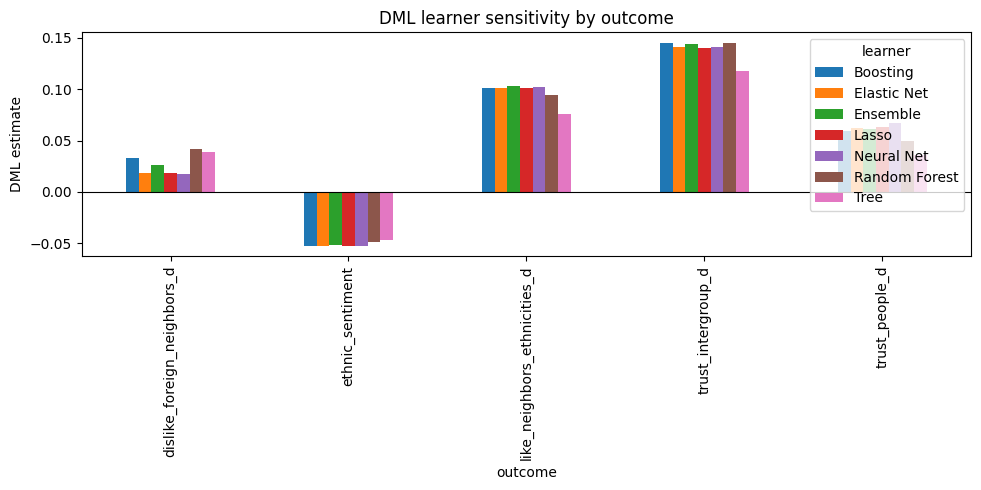

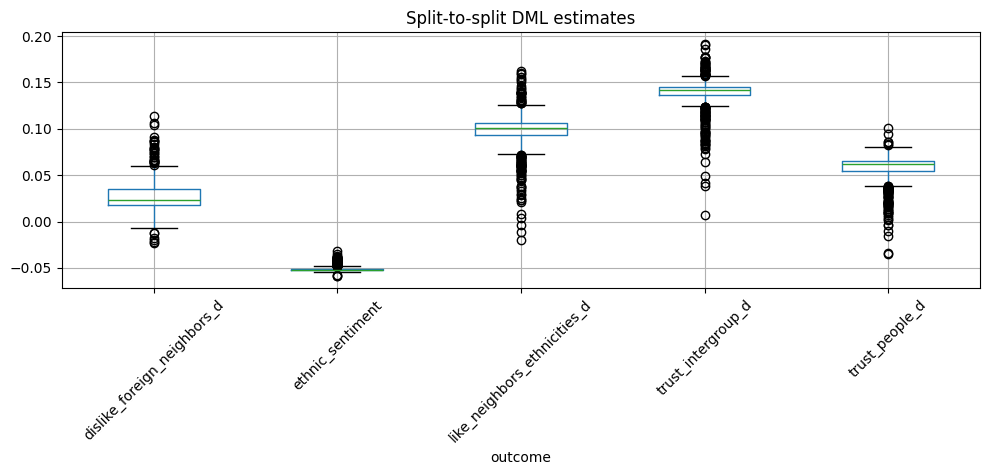

In [18]:
display(pre_estimation_diagnostics)
display(fixed_effect_support)
display(missingness_table)
display(baseline_replication_table[[
    "outcome", "original_estimate", "estimate", "se", "n", "clusters",
    "fe_iterations", "fe_converged", "fe_worst_group_mean", "replication_warning"
]])

if not results_long.empty:
    nuisance_table = results_long[[
        "outcome", "learner", "theta", "se", "y_mse", "d_mse", "d_star_sd",
        "d_tilde_sd", "denominator", "split_sd", "n", "clusters"
    ]].sort_values(["outcome", "learner"])
    display(nuisance_table)
    learner_sensitivity = results_long.pivot_table(index="outcome", columns="learner", values="theta", aggfunc="first")
    display(learner_sensitivity)
else:
    print("Run DML cells before diagnostics.")

if HAS_MATPLOTLIB and not results_long.empty:
    ax = learner_sensitivity.plot(kind="bar", figsize=(10, 5))
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_title("DML learner sensitivity by outcome")
    ax.set_ylabel("DML estimate")
    plt.tight_layout()
    plt.show()
    
    split_diagnostics.boxplot(column="theta", by="outcome", rot=45, figsize=(10, 5))
    plt.title("Split-to-split DML estimates")
    plt.suptitle("")
    plt.tight_layout()
    plt.show()
else:
    print("Plotting skipped because matplotlib is unavailable or results are empty.")

## 15. Multiple-testing diagnostic

The Benjamini–Hochberg adjustment covers the five outcomes in this notebook. It is not the paper's full false-discovery-rate family unless every original hypothesis is included.

This cell computes Benjamini–Hochberg adjusted values for the five notebook outcomes and displays baseline and DML comparisons.

In [19]:
def benjamini_hochberg(p_values):
    p = np.asarray(p_values, dtype=float)
    out = np.full_like(p, np.nan)
    valid = np.isfinite(p)
    pv = p[valid]
    m = len(pv)
    if m == 0:
        return out
    order = np.argsort(pv)
    ranked = pv[order]
    adjusted = np.empty(m)
    running = 1.0
    for i in range(m - 1, -1, -1):
        running = min(running, ranked[i] * m / (i + 1))
        adjusted[i] = running
    restored = np.empty(m)
    restored[order] = np.minimum(adjusted, 1.0)
    out[valid] = restored
    return out

baseline_replication_table["baseline_bh_q_5outcomes"] = benjamini_hochberg(baseline_replication_table["p"])
if not dml_best_learners.empty:
    dml_best_learners["dml_bh_q_5outcomes"] = benjamini_hochberg(dml_best_learners["p"])
    display(dml_best_learners[["outcome", "p", "dml_bh_q_5outcomes"]])

display(baseline_replication_table[["outcome", "p", "baseline_bh_q_5outcomes"]])
baseline_replication_table.to_csv(RESULTS_DIR / "baseline_replication_table.csv", index=False)
dml_best_learners.to_csv(RESULTS_DIR / "dml_best_learners.csv", index=False)

,outcome,p,dml_bh_q_5outcomes
0,dislike_foreign_neighbors_d,0.306437,0.306437
1,ethnic_sentiment,0.001950,0.002865
2,like_neighbors_ethnicities_d,0.001634,0.002865
3,trust_intergroup_d,0.000344,0.001718
4,trust_people_d,0.002292,0.002865


,outcome,p,baseline_bh_q_5outcomes
0,ethnic_sentiment,0.001119,0.001866
1,trust_people_d,0.003020,0.003775
2,trust_intergroup_d,0.000430,0.001855
3,like_neighbors_ethnicities_d,0.000742,0.001855
4,dislike_foreign_neighbors_d,0.278265,0.278265
